<a href="https://colab.research.google.com/github/mhosigiri/skyline-movies/blob/main/skyline_movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
debanganghosh_imdb_dataset_path = kagglehub.dataset_download('debanganghosh/imdb-dataset')

print('Data source import complete.')


100%|██████████| 175k/175k [00:00<00:00, 1.05MB/s]

Extracting files...


Data source import complete.


### **Multidimensional Data Analytics: Movies Skyline**

### In this colab, we will implement a simple algorithm for finding the best movies of all time according to IMDB. We will test the algorithm using Movies ratings and find the skyline for the IMDB top 1000 movies.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from matplotlib import pyplot as plt, rc, rcParams
from matplotlib.animation import FuncAnimation

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset/imdb_top_1000.csv


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "imdb_top_1000.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "debanganghosh/imdb-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:                                          Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

        

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

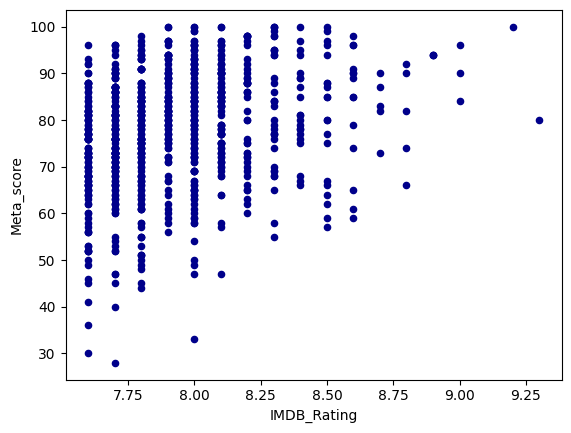

In [ ]:
df.plot.scatter(x='IMDB_Rating', y='Meta_score', c='DarkBlue')

**To make the code easier to understand and to avoid explaining DataFrame-specific best practices, lets convert the ``DataFrame`` into a NumPy array**

In [ ]:
numeric_df = df[["IMDB_Rating", "Meta_score"]].dropna()
movie_rating = numeric_df.values.tolist()
print(movie_rating)

[[9.3, 80.0], [9.2, 100.0], [9.0, 84.0], [9.0, 90.0], [9.0, 96.0], [8.9, 94.0], [8.9, 94.0], [8.9, 94.0], [8.8, 74.0], [8.8, 66.0], [8.8, 92.0], [8.8, 82.0], [8.8, 90.0], [8.7, 87.0], [8.7, 73.0], [8.7, 90.0], [8.7, 82.0], [8.7, 83.0], [8.6, 90.0], [8.6, 96.0], [8.6, 74.0], [8.6, 79.0], [8.6, 96.0], [8.6, 91.0], [8.6, 61.0], [8.6, 59.0], [8.6, 65.0], [8.6, 85.0], [8.6, 90.0], [8.6, 85.0], [8.6, 98.0], [8.6, 89.0], [8.5, 59.0], [8.5, 88.0], [8.5, 57.0], [8.5, 66.0], [8.5, 85.0], [8.5, 85.0], [8.5, 67.0], [8.5, 62.0], [8.5, 77.0], [8.5, 64.0], [8.5, 88.0], [8.5, 75.0], [8.5, 80.0], [8.5, 94.0], [8.5, 87.0], [8.5, 80.0], [8.5, 97.0], [8.5, 100.0], [8.5, 96.0], [8.5, 99.0], [8.4, 75.0], [8.4, 79.0], [8.4, 87.0], [8.4, 78.0], [8.4, 68.0], [8.4, 81.0], [8.4, 81.0], [8.4, 78.0], [8.4, 67.0], [8.4, 95.0], [8.4, 89.0], [8.4, 77.0], [8.4, 80.0], [8.4, 76.0], [8.4, 85.0], [8.4, 66.0], [8.4, 94.0], [8.4, 89.0], [8.4, 97.0], [8.4, 90.0], [8.4, 100.0], [8.3, 78.0], [8.3, 77.0], [8.3, 95.0], [8.3, 80

In [ ]:
from enum import Enum
Outcomes = Enum('Outcomes', 'DOMINATE DOMINATED NO_DOMINANCE INCOMPARABLE')

**Now we are ready to implement the skyline algorithm. First, we implement a utility function that compares two objects to determine their dominance relationship. This function will be used again and again in our algorithm. Given two points ``p`` and ``q``, this function returns one of the following values:**

-``DOMINATE``: p dominates q;
-``DOMINATED``: p is dominated by q;
-``NO_DOMINANCE``: p and q do not dominate each other;
-``INCOMPARABLE``: have different dimensionalitites and are thus incomparable

**In what scenarios are we going to declare ``p`` dominates ``q``?
It is as follows:**
-``p`` is not weaker than ``q`` on any dimension, i.e. ``p`` is stronger than or equal or stronger than ``q`` on every dimension;
-``p`` is stronger than ``q`` on atleast one dimension.

**What do we mean by "stronger" and "weaker"? That depends on the data analysis tasks in our hands. In our task of finding the best movies of all time according to IMDB rating, more IMDB rating and Meta_score are stronger performance.**

In [ ]:
def compare1(p, q):
    if len(p) != len(q): return Outcomes.INCOMPARABLE

    p_greater = False
    q_greater = False

    for i in range(len(p)):
        if p[i] < q[i]: q_greater = True
        if p[i] > q[i]: p_greater = True

    if p_greater and not q_greater:
        return Outcomes.DOMINATE
    if not p_greater and q_greater:
        return Outcomes.DOMINATED

    return Outcomes.NO_DOMINANCE

**By following the definition of skyline points, it is rather simple to implement a straightforward algorithm. It just compares every data point with every other data point. If data point ``p`` is not dominated by any other data point, it belongs to the skyline.**

In [ ]:
def straightforward(records):
    skyline = []
    comparisons = 0

    for i, p in enumerate(records):
        dominated = False

        for j, q in enumerate(records):
            if i == j:
                continue # we skip comparing point with itself

            outcome = compare1(p, q)
            comparisons += 1

            if outcome == Outcomes.DOMINATED:
                dominated = True
                break #we dont need to keep checking

        if not dominated:
            skyline.append(p)

    print("The algorithm compared " + str(comparisons) + " pairs of data points")
    return skyline



**Now lets apply the strightforward algorithm on our 2-dimensional space ``(IMDB, Meta)``. Did you guess the skyline points right?**

**This straightforward algorithm has a time complexity of O(n^2), which is apparent from the nested loops. When there are many points to consider, it is inefficient.**

In [ ]:
print("There are " + str(len(movie_rating)) + " data points,")
straightforward(movie_rating)

There are 843 data points,
The algorithm compared 2906 pairs of data points


[[9.3, 80.0], [9.2, 100.0]]

**Now we explain a more efficient algorithm. Its worse-case time-complexity is no better. It could end up taking the same time covering every pair of data points. In practice though, its very efficient.**

**This algorithm works by continuously updating the skyline while iterating through all data points. Given each data point ``p`` compares it with points in the current skyline and updates the skyline as follows:**

* If p dominates an existing point q in the current skyline, q is kicked out of the current skyline. In fact, it is discarded forver since we can be sure it cannot be part of the skyline.
* if p is dominated by an existing point q in the current skyline, then p can be discarded and it is unnecessary to further compare it with the rest of the points in the dataset.
* If p is not dominated by any existing point in the current skyline, the current skyline is updated to include p.

**Now that we compare p[i] and q[i] because we only need the imdb score and the meta score and we dont want to include any strings in the comaprisons.**

In [ ]:
def alg1(records):
    skyline = []
    comparisons = 0

    for p in records:
        updated = []
        dominated = False

        for q in skyline:
            outcome = compare1(p, q)
            comparisons += 1

            # If p is dominated, stop checking and discard p
            if outcome == Outcomes.DOMINATED:
                dominated = True
                break

            # If p dominates q, we do not keep q
            if outcome == Outcomes.DOMINATE:
                continue

            #Otherwise we keep q
            updated.append(q)

        # If p was not dominated, add it to skyline
        if not dominated:
            skyline = updated
            skyline.append(p)

    print("The algorithm compared ", comparisons, " pairs of data points.")
    return skyline

In [ ]:
alg1(movie_rating)

The algorithm compared  1223  pairs of data points.


[[9.3, 80.0], [9.2, 100.0]]

**The algorithm only required 1223 pairs of comparisons, in contrast with the 2906 comparisons taken by the straightforward algorithm.**

**Now we visualize how the skyline algorithm compares two given points**

In [ ]:
def alg1_animate(records):
    skyline = []
    ani_points = []

    for p in records:
        updated = []
        dominated = False

        ani_points.append([p[0], p[1], 'yellow'])

        for q in skyline:

            ani_points.append([q[0], q[1], 'green'])

            outcome = compare1(p, q)

            if outcome == Outcomes.DOMINATED:
                ani_points.append([p[0], p[1], 'grey'])
                ani_points.append([q[0], q[1], 'red'])
                dominated = True
                break

            if outcome == Outcomes.DOMINATE:
                ani_points.append([q[0], q[1], 'grey'])
            else:
                updated.append(q)
                ani_points.append([q[0], q[1], 'red'])

        if not dominated:
            skyline = updated
            skyline.append(p)

            ani_points.append([p[0], p[1], 'red'])

    return ani_points

KeyboardInterrupt: 

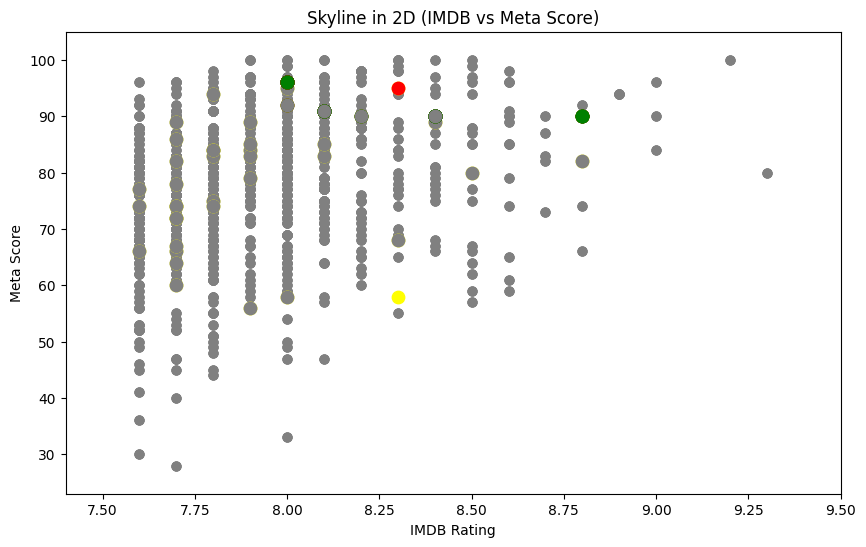

In [ ]:
rcParams["animation.embed_limit"] = 2**128

# Animation skyline builder
def alg1_animate(records):
    skyline = []
    ani_points = []

    for p in records:
        updated = []
        dominated = False

        # Current point (yellow)
        ani_points.append([p[0], p[1], 'yellow'])

        for q in skyline:

            # Existing skyline point (green)
            ani_points.append([q[0], q[1], 'green'])

            outcome = compare1(p, q)

            if outcome == Outcomes.DOMINATED:
                # p discarded
                ani_points.append([p[0], p[1], 'grey'])
                dominated = True
                break

            if outcome == Outcomes.DOMINATE:
                # q removed
                ani_points.append([q[0], q[1], 'grey'])
            else:
                updated.append(q)
                ani_points.append([q[0], q[1], 'red'])

        if not dominated:
            skyline = updated
            skyline.append(p)
            ani_points.append([p[0], p[1], 'red'])

    return ani_points


# Setup plot
fig = plt.figure(figsize=(10,6))
ax = plt.axes(
    xlim=(min(records[:,0]) - 0.2, max(records[:,0]) + 0.2),
    ylim=(min(records[:,1]) - 5, max(records[:,1]) + 5)
)

ax.set_xlabel("IMDB Rating")
ax.set_ylabel("Meta Score")
ax.set_title("Skyline in 2D (IMDB vs Meta Score)")

ani_points = alg1_animate(records)

# Initial plot (all grey)
def init():
    sc = ax.scatter(records[:,0], records[:,1], color='grey', s=40)
    return sc,

# Frame update
def animate(i):
    x, y, color = ani_points[i]
    sc = ax.scatter(x, y, color=color, s=80)
    return sc,

ani = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(ani_points),
    interval=40,
    blit=True
)

rc('animation', html='jshtml')
ani

**Now lets find the skyline records in more than two dimensions. The following is a visualization using radar chart. We are focusing on a 3D subspace ``(IMDB Rating, Meta Score and Total Votes).`` Each movie is visualized as a polygon i.e. a triangle for the 3D subspace. To make the visualization legible, we are only considering the absolute best movies--Those with atleast 7.0 rating and 70% or higher.**

**How does it look like when a movie is dominated by another movie? Its polygon is completely enclosed by the other movie's polygon. Hence, the skyline movies are those whose polygons are not enclosed. In this radar chart, what are the colors of the skyline records' polygons?**

### Step 1: We prepare the Movie Data (3D subspace)

In [ ]:
import numpy as np
import pandas as pd

df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce")

filtered = df[
    (df["IMDB_Rating"] >= 8.5) &
    (df["Meta_score"] >= 90)
].dropna(subset=["IMDB_Rating", "Meta_score", "No_of_Votes"])

movies_3d = filtered[["Series_Title", "IMDB_Rating", "Meta_score", "No_of_Votes"]].copy()

### Step 2: Normalize values for Radar plot

We normalize each column to 0-3 scale

In [ ]:
for col in ["IMDB_Rating", "Meta_score", "No_of_Votes"]:
    min_val = movies_3d[col].min()
    max_val = movies_3d[col].max()
    movies_3d[col] = 3 * (movies_3d[col] - min_val) / (max_val - min_val)

### Step 3: Compute Skyline in 3D

We reuse our ``compare1`` and skyline algorithm:

In [ ]:
records = movies_3d[["IMDB_Rating", "Meta_score", "No_of_Votes"]].values.tolist()
skyline_records = alg1(records)

# Convert skyline list to set for quick lookup
skyline_set = set(tuple(x) for x in skyline_records)

The algorithm compared  21  pairs of data points.


### Step 4: Radar Chart code (Movies Version)

In [ ]:
import pylab as pl
import matplotlib.pyplot as py

class Radar(object):
    def __init__(self, fig, titles, labels, rect=None):
        if rect is None:
            rect = [0.05, 0.05, 0.95, 0.95]

        self.n = len(titles)
        self.angles = np.linspace(0,360, self.n, endpoint=False)
        self.axes = [fig.add_axes(rect, projection="polar")]

        self.ax = self.axes[0]
        self.ax.set_thetagrids(self.angles, labels=titles, fontsize=12, weight="bold")

        self.ax.set_ylim(0, 3)
        self.ax.grid(True)

    def plot(self, values, *args, **kw):
        angle = np.deg2rad(np.r_[self.angles, self.angles[0]])
        values = np.r_[values, values[0]]
        self.ax.plot(angle, values, *args, **kw)
        self.ax.fill(angle, values, alpha=0.05)



### Step 5: Plot with Skyline Highlighting

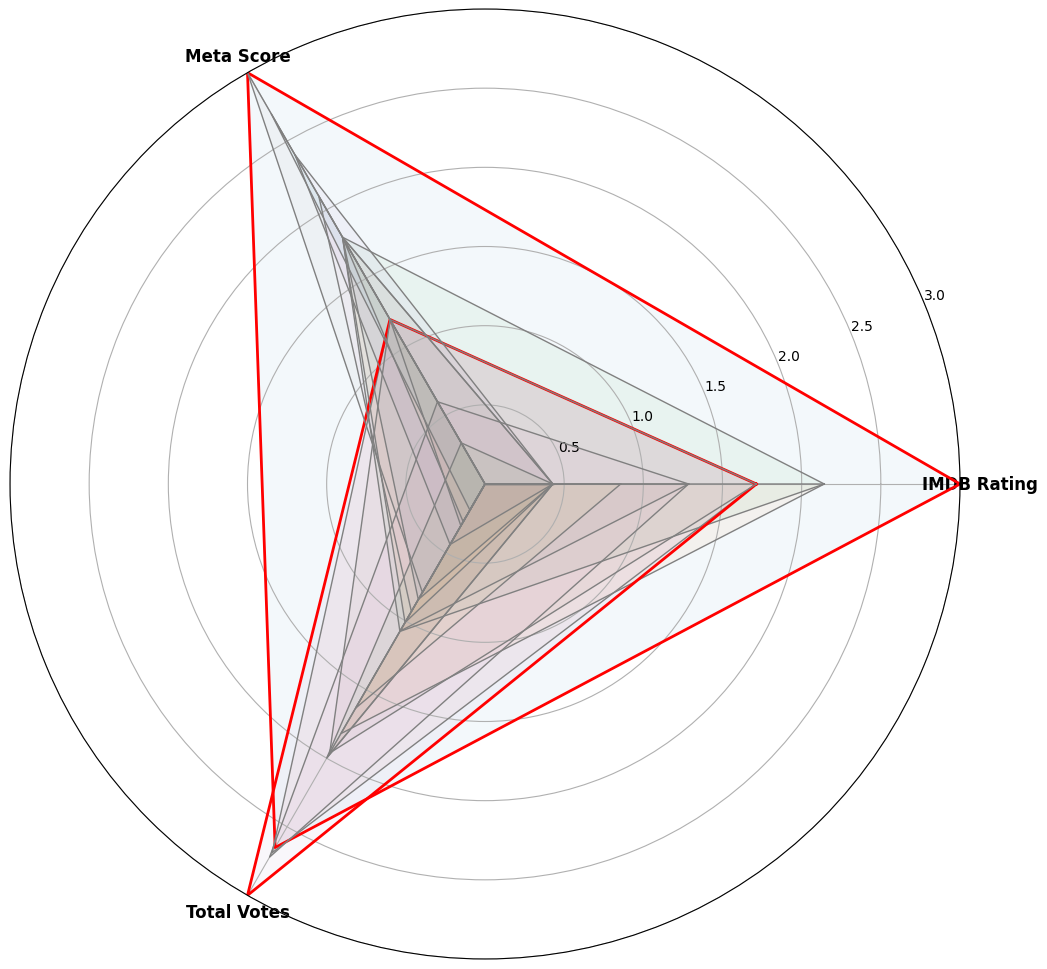

In [ ]:
fig = pl.figure(figsize=(10, 10))

titles = ["IMDB Rating", "Meta Score", "Total Votes"]
labels = [["Low", "Mid", "High"]] * 3

radar = Radar(fig, titles, labels)

for _, row in movies_3d.iterrows():
    values = row[["IMDB_Rating", "Meta_score","No_of_Votes"]].values.tolist()

    if tuple(values) in skyline_set:
        radar.plot(values, linewidth=2, linestyle='solid', color='red')
    else:
        radar.plot(values, linewidth=1, linestyle='solid', color='grey')

pl.show()

### Inference

**We cannot really eyeball skyline points out of a large dataset. We observe from the execution results that the larger the dimensionality, the more skyline points and the more comparisons required to find the skyline points. Usually the purpose of skyline analysis is to locate a small number of extraordinary records. A large skyline is not very helpful in practice. In other words, skyline analysis is less useful in a subspace with high dimensionality.**